In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os
from pathlib import Path
import shutil
import torch

In [8]:
ds = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc"))

print(ds.data_vars)
print(ds.latitude.values)
print(ds.longitude.values)

Data variables:
    q        (time, isobaricInhPa, latitude, longitude) float32 5GB ...
[-25.   -25.25 -25.5  -25.75 -26.   -26.25 -26.5  -26.75 -27.   -27.25
 -27.5  -27.75 -28.   -28.25 -28.5  -28.75 -29.   -29.25 -29.5  -29.75
 -30.   -30.25 -30.5  -30.75 -31.   -31.25 -31.5  -31.75 -32.   -32.25
 -32.5  -32.75 -33.   -33.25 -33.5  -33.75 -34.   -34.25 -34.5  -34.75
 -35.  ]
[-60.   -59.75 -59.5  -59.25 -59.   -58.75 -58.5  -58.25 -58.   -57.75
 -57.5  -57.25 -57.   -56.75 -56.5  -56.25 -56.   -55.75 -55.5  -55.25
 -55.   -54.75 -54.5  -54.25 -54.   -53.75 -53.5  -53.25 -53.   -52.75
 -52.5  -52.25 -52.   -51.75 -51.5  -51.25 -51.   -50.75 -50.5  -50.25
 -50.   -49.75 -49.5  -49.25 -49.   -48.75 -48.5  -48.25 -48.   -47.75
 -47.5  -47.25 -47.   -46.75 -46.5  -46.25 -46.   -45.75 -45.5  -45.25
 -45.  ]


# NC FILES ENGINEERING


In [8]:
ds = xr.open_dataset(r"C:\Users\bruno\Downloads\2dd72215f9745c336b6829e548fbbfad\data.grib")

print(ds.dims)
print(ds.data_vars)
print(ds.time.values)
print(ds.isobaricInhPa.values)
print(ds.time.values.shape)

FrozenMappingWarningOnValuesAccess({'time': 8760, 'isobaricInhPa': 2, 'latitude': 41, 'longitude': 61})
Data variables:
    u        (time, isobaricInhPa, latitude, longitude) float32 175MB ...
    v        (time, isobaricInhPa, latitude, longitude) float32 175MB ...
['1989-01-01T00:00:00.000000000' '1989-01-01T01:00:00.000000000'
 '1989-01-01T02:00:00.000000000' ... '1989-12-31T21:00:00.000000000'
 '1989-12-31T22:00:00.000000000' '1989-12-31T23:00:00.000000000']
[850. 500.]
(8760,)


In [9]:
converted = ds.to_netcdf(r"C:\Local Repository\LSTM-GNN\Datasets\nc_files\era5_wind_89.nc")

In [28]:
file_list = []


for i in range(0,14):
    file_list.append(xr.open_dataset(r"C:\Local Repository\LSTM-GNN\Datasets\nc_files\era5_wind_"+str(i)+".nc"))



for i in range(len(file_list)):
    print(i,file_list[i].time.values)

arx = xr.concat([file for file in file_list] , dim='time')

print(arx.time.values, arx.time.values.shape)


#arx.to_netcdf(r"C:\Local Repository\LSTM-GNN\Datasets\nc_files\era5_wind_93-99.nc")
#arx = xr.concat([file_2, file_1], dim='time')
#print(arx.time.values)
#print(arx.time.values.shape)

0 ['2000-01-01T00:00:00.000000000' '2000-01-01T01:00:00.000000000'
 '2000-01-01T02:00:00.000000000' ... '2000-12-31T21:00:00.000000000'
 '2000-12-31T22:00:00.000000000' '2000-12-31T23:00:00.000000000']
1 ['2001-01-01T00:00:00.000000000' '2001-01-01T01:00:00.000000000'
 '2001-01-01T02:00:00.000000000' ... '2001-12-31T21:00:00.000000000'
 '2001-12-31T22:00:00.000000000' '2001-12-31T23:00:00.000000000']
2 ['2002-01-01T00:00:00.000000000' '2002-01-01T01:00:00.000000000'
 '2002-01-01T02:00:00.000000000' ... '2002-12-31T21:00:00.000000000'
 '2002-12-31T22:00:00.000000000' '2002-12-31T23:00:00.000000000']
3 ['2003-01-01T00:00:00.000000000' '2003-01-01T01:00:00.000000000'
 '2003-01-01T02:00:00.000000000' ... '2003-12-31T21:00:00.000000000'
 '2003-12-31T22:00:00.000000000' '2003-12-31T23:00:00.000000000']
4 ['2004-01-01T00:00:00.000000000' '2004-01-01T01:00:00.000000000'
 '2004-01-01T02:00:00.000000000' ... '2004-12-31T21:00:00.000000000'
 '2004-12-31T22:00:00.000000000' '2004-12-31T23:00:00.00

In [ ]:
arx.to_netcdf(r"C:\Local Reposity\LSTM-GNN\Datasets\nc_files\cape_01-26.nc")

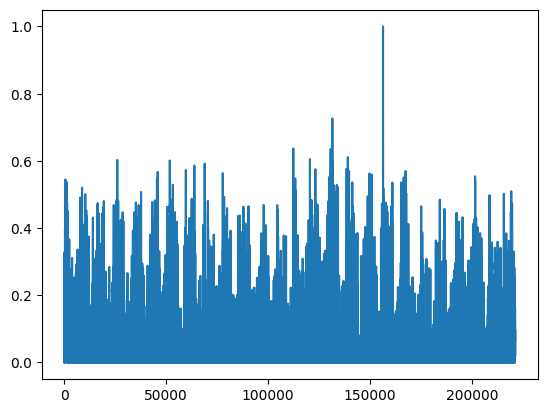

In [ ]:
cape1 = arx.cape.values[:,0,0]
scaler_cape = MinMaxScaler()
cape1_scaled = scaler_cape.fit_transform(cape1.reshape(-1,1))

#plt.hist(cape1_scaled, bins=50)

plt.plot(cape1_scaled.reshape(-1,1))

In [ ]:
#converte um arquivo .grib para um arquivo .nc
print("started")
import xarray as xr
import numpy as np

file_2 = xr.open_dataset(r"C:\Local Repository\LSTM-GNN\Datasets\nc_files\cape_01-26.nc")

file_1 = xr.open_dataset(r"C:\Local Repository\LSTM-GNN\Datasets\nc_files\cape_88-00.nc")


ds = xr.concat([file_1,file_2], dim='time')

print(ds.time.values)


ds.to_netcdf(r"C:\Local Repository\LSTM-GNN\Datasets\nc_files\cape_88-26.nc")

#file_2_ = file_2.drop_sel(time="2018-12-31 18:00")

ds.to_netcdf(r"C:\Local Repository\LSTM-GNN\Datasets\nc_files\cape_88-26.nc")

#ds = xr.concat([file_1, file_2],dim='time')
 
#print(ds.sel(time="2018-12-31 18:00", latitude=-25.25, longitude=-59.25).tp.values)

#ds.sel(time="2018-12-31 18:00").tp.values[5:] = file_2.sel(time="2018-12-31 18:00").tp.values[5:]

#print(ds.sel(time="2018-12-31 18:00", latitude=-25.25, longitude=-59.25).tp.values)


#ds.to_netcdf(r"C:\Climate Change Project\Datasets\era5_precipitation_80-26.nc")




started
['1988-01-01T00:00:00.000000000' '1988-01-01T01:00:00.000000000'
 '1988-01-01T02:00:00.000000000' ... '2026-03-22T16:00:00.000000000'
 '2026-03-22T17:00:00.000000000' '2026-03-22T18:00:00.000000000']


# MULTI PLOT SHOW


In [ ]:
base_path = Path(os.path.join("..", "Experiments", "date_05_05", "TRANSFORMERS", "dataset_00_25", "head_v2"))

path_destiny = Path(os.path.join(base_path,"Forecast Plots"))

path_destiny.mkdir(parents=True, exist_ok=True)

file_names = "previsão.png"

models_dict = []


for window_folder in base_path.glob("WINDOW_*"):
    print(window_folder)
    if window_folder.is_dir():
        print(f"Entrando em {window_folder.name}")
        
        for exp_folder in window_folder.glob("exp_*"):
            if exp_folder.is_dir():
                for file in exp_folder.rglob("*"):
                    if file.is_file() and file.name == file_names:
                        new_name = f"{window_folder.name}_{exp_folder.name}_{file.name}"
                        shutil.copy2(file, path_destiny / new_name)
                        print(f"Copiado: {file}")
                        models_dict.append(torch.load(os.path.join(exp_folder, "model_state_dict.pt")))

..\Experiments\date_05_05\TRANSFORMERS\dataset_00_25\head_v2\WINDOW_30_HORIZON_1_DROP_0.0+WMSE_0.7_quantile
Entrando em WINDOW_30_HORIZON_1_DROP_0.0+WMSE_0.7_quantile
Copiado: ..\Experiments\date_05_05\TRANSFORMERS\dataset_00_25\head_v2\WINDOW_30_HORIZON_1_DROP_0.0+WMSE_0.7_quantile\exp_001\previsão.png
Copiado: ..\Experiments\date_05_05\TRANSFORMERS\dataset_00_25\head_v2\WINDOW_30_HORIZON_1_DROP_0.0+WMSE_0.7_quantile\exp_002\previsão.png
Copiado: ..\Experiments\date_05_05\TRANSFORMERS\dataset_00_25\head_v2\WINDOW_30_HORIZON_1_DROP_0.0+WMSE_0.7_quantile\exp_003\previsão.png
Copiado: ..\Experiments\date_05_05\TRANSFORMERS\dataset_00_25\head_v2\WINDOW_30_HORIZON_1_DROP_0.0+WMSE_0.7_quantile\exp_004\previsão.png
Copiado: ..\Experiments\date_05_05\TRANSFORMERS\dataset_00_25\head_v2\WINDOW_30_HORIZON_1_DROP_0.0+WMSE_0.7_quantile\exp_005\previsão.png
Copiado: ..\Experiments\date_05_05\TRANSFORMERS\dataset_00_25\head_v2\WINDOW_30_HORIZON_1_DROP_0.0+WMSE_0.7_quantile\exp_006\previsão.png
Copia